# Fusarium head blight severity from hill-plot hyperspectra — ordinal SVM reproduction

Reproduction of **Żelazny, Chrpová & Hamouz (2021), "Fusarium head blight detection from
spectral measurements in a field phenotyping setting — a pre-registered study",
*Biosystems Engineering* 211:97–113** ([DOI 10.1016/j.biosystemseng.2021.08.019](https://doi.org/10.1016/j.biosystemseng.2021.08.019), CC-BY).
Data and R scripts: Zenodo record [4536881](https://doi.org/10.5281/zenodo.4536881) (AGPL-3.0, v1.0.0).

**Scope — ADAPTED PYTHON DEMONSTRATION (one minimal example).** This notebook re-implements the
paper's ordinal support-vector-machine pipeline in Python and runs the **median-aggregation half
of the reported evaluation**: 4 spectral/ground-truth timing combinations × 7 spectral
pre-processing schemes × 10 jack-knife train/validation partitions = **280 model ensembles**,
scored by validation accuracy at 0/1/2-class error tolerance. Omitted: the mean-aggregation
half, the Bayesian mixed-effect modelling of prediction success (`brms`), and remaining figures.

**AI-assisted adaptation notice (EN):** This notebook is an AI-assisted Python translation of the
authors' R implementation (Zenodo 4536881, `R/01`–`R/11`); the authors did not provide this
Colab implementation. The executed example and listed checks were validated, but untested
behavior is not guaranteed. Every adapted step is mapped to the author function it follows.
**JP:** 本ノートブックは著者のR実装をAIがPythonへ翻訳した適応版デモです。著者自身のColab実装ではありません。実行例と検証内容は確認済みですが、未検証の動作は保証されません。

**Execution status:** CPU-only demonstration; validated end-to-end on a fresh Colab CPU runtime
(timings printed by the cells below; see the accompanying report for the validation record).

**JP summary:** 本ノートブックは、冬コムギ穂のハイスペクトル(350–2500 nm)と専門家による9段階発症度(VSS)から、順序型SVMで丘圃(hill plot)のVSSを予測する解析を再現します。生データ取得→放物線補正→中央値集約→7種の前処理→順序型SVM学習(LOO交差検証でコスト/γを選択)→0/1/2クラス許容精度の評価までをColab CPU上で実行します(280アンサンブル、目安45–90分)。

## Runtime selection — CPU only

**Select `Runtime → Change runtime type → CPU` (standard).** No GPU is used anywhere: the method
trains ≤7 small RBF-SVMs per ensemble on ≤36 samples × ≤1851 bands (libsvm via scikit-learn),
and the author implementation (R `e1071`) is CPU-only too.

Expected resources (estimates; measured values are printed by the cells): ~35 MB Zenodo
download, <2 GB RAM, roughly 45–90 min end to end on a free Colab CPU VM, dominated by the
100-point cost/γ grid × leave-one-out tuning of 280 ensembles. All required packages
(numpy, pandas, scipy, scikit-learn, joblib, matplotlib) are preinstalled in Colab.

**JP:** GPUは不要です(CPUのみ)。ダウンロード約35MB、Free Colab CPUで目安45–90分です。ランタイムはCPU(標準)を選択してください。

In [ ]:
import sys
import numpy as np, pandas as pd, scipy, sklearn, matplotlib, joblib
print("python:", sys.version.split()[0])
for m in (np, pd, scipy, sklearn, matplotlib, joblib):
    print(m.__name__, m.__version__)
print("This reproduction is CPU-only; no CUDA/GPU code is used.")

python: 3.13.16
numpy 2.1.3
pandas 2.2.3
scipy 1.16.3
sklearn 1.6.1
matplotlib 3.10.0
joblib 1.6.0
This reproduction is CPU-only; no CUDA/GPU code is used.


## Data acquisition — Zenodo record 4536881 (all bytes downloaded inside Colab)

The authors distribute data and scripts as one archive: `zelazny2021fusarium.tar.gz`,
**34,454,227 bytes, md5 `5391e40aa2bb5066c7db25192c03edca`**, record DOI
`10.5281/zenodo.4536881`, version 1.0.0 (2021-08-25), license AGPL-3.0. The cell verifies size
**and** md5 before extraction and fails loudly on mismatch.

**JP:** Zenodoのアーカイブ(34,454,227バイト)をColab内にダウンロードし、サイズとMD5を検証してから展開します。

In [ ]:
import urllib.request, hashlib, os, tarfile

URL = "https://zenodo.org/records/4536881/files/zelazny2021fusarium.tar.gz?download=1"
TAR = "/content/zelazny2021fusarium.tar.gz"
EXPECTED_SIZE, EXPECTED_MD5 = 34_454_227, "5391e40aa2bb5066c7db25192c03edca"

if not os.path.exists(TAR):
    for attempt in range(1, 4):
        try:
            urllib.request.urlretrieve(URL, TAR)
            break
        except Exception as e:
            print(f"download attempt {attempt} failed: {e}")
            if attempt == 3:
                raise

size = os.path.getsize(TAR)
h = hashlib.md5()
with open(TAR, "rb") as f:
    for chunk in iter(lambda: f.read(1 << 20), b""):
        h.update(chunk)
print("size:", size, "md5:", h.hexdigest())
assert size == EXPECTED_SIZE and h.hexdigest() == EXPECTED_MD5, "checksum mismatch"
print("checksum OK")

if not os.path.isdir("/content/fhb"):
    with tarfile.open(TAR) as tf:
        try:
            tf.extractall("/content/fhb", filter="data")
        except TypeError:  # older Python without the filter argument
            tf.extractall("/content/fhb")
print("extracted to /content/fhb")

size: 34454227 md5: 5391e40aa2bb5066c7db25192c03edca
checksum OK


extracted to /content/fhb


The archive is the authors' full repository (numbered R pipeline, tests, a GNU Guix manifest
and this dataset). The cell lists the inventory and locates the data files this demo needs.

**JP:** アーカイブ内容を一覧表示し、必要なデータファイルを確認します。

In [ ]:
import os
BASE = "/content/fhb/zelazny2021fusarium"
for root, dirs, files in os.walk(BASE):
    dirs[:] = [d for d in dirs if d != "build"]
    for f in sorted(files):
        p = os.path.join(root, f)
        print(f"{os.path.getsize(p):>10} {os.path.relpath(p, BASE)}")

        31 .gitattributes
         6 .gitignore
     34523 COPYING
      5611 Makefile
      3545 README.md
       383 channel-specs.scm
       106 guix-environment.sh
       375 manifest.scm
      4173 R/01-wrangle.R
      2483 R/02-partition.R
      2062 R/03-ratings_in_partitions.R
      4514 R/03f-ratings_in_partitions.R
      3500 R/04-reflectance.R
      2292 R/05-aggregate.R
      5222 R/06-preprocess.R
      5764 R/06f-preprocess.R
      7843 R/07-model.R
      4587 R/08-predict.R
      2354 R/09-add_tolerances.R
      2134 R/10-confmatrix.R
      2522 R/11-evaluate.R
      3027 R/11f-evaluate.R
      4295 R/12-augment_confmatrices.R
      6034 R/12f-augment_confmatrices.R
      2554 R/13-lm.R
      2634 R/14-draw.R
      3149 R/14f-draw.R
      3826 R/15-contrast_dates.R
      6721 R/15t-contrast_dates.R
      3476 R/16-contrast_preprocessings.R
      6518 R/16t-contrast_preprocessings.R
      1955 R/17-vss_concordance.R
      2377 R/17f-vss_concordance.R
       685 R/constant

## Wrangling — spectra ↔ hill plots ↔ expert ratings

Follows author `R/01-wrangle.R` + `R/02-partition.R` semantics: `spectra_filenames.csv` expands
each filename range into the individual measurement files of a hill plot (5 spectra per plot: a
spike cluster measured 5×), spectra are matched by the date+index part of the filename, and a
**hill-plot pair** is kept only when **all four** `(campaign, treatment)` combinations
(early/late × fusarium/control) have exactly 5 spectra. Expert 9-point VSS ratings
(`ground_truth.csv`: 9 = <5% … 1 = >95% infected spikelets, higher = less severe) are joined per
rating campaign. Following `R/02-partition.R`, pairs whose **late-date control plot was rated
below 9** (symptoms in the non-inoculated facing plot) are excluded; the paper reports **48
retained pairs** (§2.3). Note that pair identifiers are strings (e.g. `735/3`).

**JP:** ファイル名範囲を展開して各丘圃の5スペクトルを対応付け、4组合(時期×処理)が揃うペアのみ残します。専門家の9段階VSS評価を結合し、対照圃に症状が出たペア(遅期評価≠9)を除外します。論文では48ペアが残ります。

In [ ]:
import collections
DATA = f"{BASE}/data"

fn = pd.read_csv(f"{DATA}/spectra_filenames.csv")
fn["date"] = fn["date"].astype(str)
rows = []
for _, r in fn[fn.device == "spectroradiometer"].iterrows():
    for f in range(int(r["filename_start"]), int(r["filename_end"]) + 1):
        rows.append((r["date"], r["treatment"], str(r["pair"]), str(f)))
fnmap = pd.DataFrame(rows, columns=["date", "treatment", "pair", "filename"])

srm = pd.read_csv(f"{DATA}/spectroradiometer.csv.gz")
srm["date8"] = srm["filename"].astype(str).str[:8]
srm["idx"] = srm["filename"].astype(str).str[8:].astype(int).astype(str)
m = srm.merge(fnmap, left_on=["date8", "idx"], right_on=["date", "filename"], how="inner")
n_matched, n_total = len(m) // 2151, len(srm) // 2151
print("matched spectra:", n_matched,
      "| unmatched ('bad spectra' removed by author join):", n_total - n_matched)

counts = m.groupby(["date", "treatment", "pair"]).idx.nunique()
have = collections.defaultdict(set)
for (d, t, p) in counts[counts == 5].index:
    have[p].add((d, t))
ALL4 = {("20200617", "fusarium"), ("20200617", "control"),
        ("20200701", "fusarium"), ("20200701", "control")}
wrangled_pairs = sorted((p for p, s in have.items() if s == ALL4), key=str)
print("complete pairs (4/4 combos x 5 spectra):", len(wrangled_pairs),
      "=> spectra:", len(wrangled_pairs) * 20, "(paper: 67 pairs / 1340 spectra)")

gt = pd.read_csv(f"{DATA}/ground_truth.csv")
gt["date"] = gt["date"].astype(str)
gt["pair"] = gt["pair"].astype(str)
gtm = gt.merge(pd.DataFrame(wrangled_pairs, columns=["pair"]), on="pair")
n_rat = gtm[gtm.treatment == "fusarium"].groupby("pair").size()
assert (n_rat == 2).all(), "fusarium pair missing a campaign rating"

# author 02-partition: exclude pairs whose LATE control rating != 9 (rated 2020-07-02)
late_ctrl_bad = set(gtm[(gtm.date == "2020-07-02") & (gtm.treatment == "control") &
                        (gtm.rating != 9)].pair)
early_rated = set(gtm[(gtm.date == "2020-06-17") & (gtm.treatment == "fusarium")].pair)
pool = sorted((p for p in wrangled_pairs if p in early_rated and p not in late_ctrl_bad),
              key=str)
print("retained pairs (partition pool):", len(pool), "(paper: 48)",
      "| excluded control-infected:", len(late_ctrl_bad))

matched spectra: 1390 | unmatched ('bad spectra' removed by author join): 23


complete pairs (4/4 combos x 5 spectra): 67 => spectra: 1340 (paper: 67 pairs / 1340 spectra)
retained pairs (partition pool): 48 (paper: 48) | excluded control-infected: 19


## Input preview 1 — expert VSS ratings (the reference annotations)

Distribution of the expert 9-point VSS ratings that serve as ground truth, per rating campaign
(2020-06-17 = "early", milk-ripening, 14 dai; 2020-07-01 = "late", wax-ripening, 28 dai).
Lower ratings = more severe infection. The paper's Fig. 4 shows the same variable per partition.

**JP:** 教師データとなる専門家VSS評価の分布です。値が小さいほど症状が重く、遅期(7月1日)の方が低い値(重い症状)にシフトします。

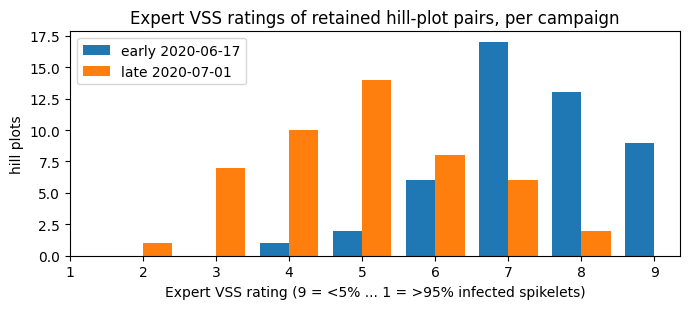

In [ ]:
import matplotlib.pyplot as plt

pool_gt = gtm[(gtm.treatment == "fusarium") & gtm.pair.isin(pool)]
fig, ax = plt.subplots(figsize=(7, 3.2))
width = 0.4
for i, (lab, ddate) in enumerate([("early 2020-06-17", "2020-06-17"),
                                  ("late 2020-07-01", "2020-07-01")]):
    counts_r = pool_gt[pool_gt.date == ddate].rating.value_counts().sort_index()
    ax.bar(counts_r.index + (i - 0.5) * width, counts_r.values, width=width, label=lab)
ax.set_xlabel("Expert VSS rating (9 = <5% ... 1 = >95% infected spikelets)")
ax.set_ylabel("hill plots")
ax.set_xticks(range(1, 10))
ax.legend()
ax.set_title("Expert VSS ratings of retained hill-plot pairs, per campaign")
fig.tight_layout()
plt.show()

## Reflectance pipeline — parabolic correction, noise trimming, median aggregation

Faithful port of author `R/04-reflectance.R` + `R/05-aggregate.R`: keep 425–2275 nm (the noisy
detector regions below 425 nm and above 2275 nm are removed, §2.2), apply the authors' parabolic
correction across the ASD Fieldspec detector transitions (multipliers on 725–1000 nm and
1801–1950 nm built from the reflectance ratios at 1000/1001 and 1800/1801 nm), then aggregate
each plot's 5 spectra with the **median**, per band. The paper's mean aggregation is omitted in
this demo (documented scope).

**JP:** 著者コード通り、425–2275 nmへトリミングし、検出器境界の放物線補正(725–1000 nm、1801–1950 nm)を施してから、丘圃ごとの5スペクトルをバンド毎の中央値で集約します。

In [ ]:
wl_all = np.sort(m.wavelength_nm.unique())
piv = m.pivot_table(index=["date", "treatment", "pair", "idx"],
                    columns="wavelength_nm", values="reflectance_factor")
assert len(piv) == n_matched, "duplicate spectrum keys in pivot"
piv = piv.reindex(columns=wl_all)
arr = piv.to_numpy()
keys = piv.index.to_frame(index=False)

w = wl_all.astype(float)
r1000, r1001 = arr[:, wl_all == 1000], arr[:, wl_all == 1001]
r1800, r1801 = arr[:, wl_all == 1800], arr[:, wl_all == 1801]
mask1, mask3 = (w >= 725) & (w <= 1000), (w >= 1801) & (w <= 1950)
mult = np.ones_like(arr)
m1 = (((w - 725.0) ** 2) * (r1001 - r1000)) / (r1000 * (1000.0 - 725.0) ** 2) + 1.0
m3 = (((w - 1950.0) ** 2) * (r1800 - r1801)) / (r1801 * (1800.0 - 1950.0) ** 2) + 1.0
mult[:, mask1] = m1[:, mask1]
mult[:, mask3] = m3[:, mask3]
arr = arr * mult
keep_wl = (w >= 425) & (w <= 2275)
arr, wls = arr[:, keep_wl], w[keep_wl]
print("bands kept:", len(wls), f"({wls[0]:.0f}-{wls[-1]:.0f} nm)")

groups = keys.groupby(["date", "treatment", "pair"]).indices
aggregated = {}
skipped = 0
for k, idx in groups.items():
    a = arr[idx]
    if a.shape[0] != 5:  # incomplete plots are excluded by the wrangle step above
        skipped += 1
        continue
    aggregated[k] = np.median(a, axis=0)
print("aggregated plot-spectra:", len(aggregated), "| skipped incomplete:", skipped)

bands kept: 1851 (425-2275 nm)
aggregated plot-spectra: 278 | skipped incomplete: 0


## Input preview 2 — median-aggregated signatures per VSS (paper Fig. 3 style)

For the early (milk-ripening) campaign, the median of the median-aggregated fusarium spectra is
plotted for each expert VSS rating, as in the paper's Fig. 3 (top panel). More severe infection
(lower ratings) shows the documented pattern: **higher reflectance in the visible region**
(pigment breakdown) and a **lower NIR plateau**. This is an input-inspection figure recreated
for this notebook, not a copy of the author figure.

**JP:** 著者論文Fig.3相当の入力確認図です。症状が重いほど(評価値が小さいほど)可視域の反射率が高く、NIRが低下します。

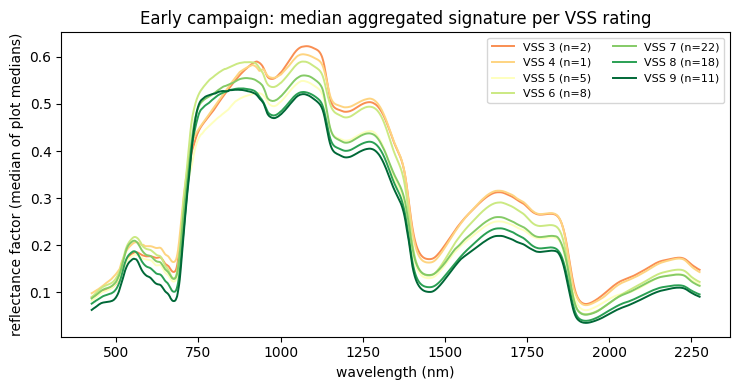

In [ ]:
fus_early = {k: v for k, v in aggregated.items()
             if k[0] == "20200617" and k[1] == "fusarium"}
rating_of_pair = dict(zip(gtm[(gtm.treatment == "fusarium") &
                             (gtm.date == "2020-06-17")].pair,
                          gtm[(gtm.treatment == "fusarium") &
                              (gtm.date == "2020-06-17")].rating))
rated = {}
for k, v in fus_early.items():
    r = rating_of_pair.get(k[2])
    if r is not None:
        rated.setdefault(int(r), []).append(v)
fig, ax = plt.subplots(figsize=(7.5, 4))
cmap = plt.get_cmap("RdYlGn")
for rating in sorted(rated):
    sigs = np.stack(rated[rating])
    ax.plot(wls, np.median(sigs, axis=0), lw=1.4, color=cmap((rating - 1) / 8),
            label=f"VSS {rating} (n={len(sigs)})")
ax.set_xlabel("wavelength (nm)")
ax.set_ylabel("reflectance factor (median of plot medians)")
ax.set_title("Early campaign: median aggregated signature per VSS rating")
ax.legend(ncol=2, fontsize=8)
fig.tight_layout()
plt.show()

## Spectral pre-processing — the paper's 7 schemes after aggregation

Faithful port of author `R/06-preprocess.R`: `none` (raw), `subtract` (minus the aggregated
**non-inoculated counterpart** spectrum of the same pair/campaign), `divide` (ratio to it),
`snv` (standard normal variate; R's `sd` → ddof=1), `subtractsnv`, `dividesnv`, and `whetton`
(maximum normalisation → Savitzky–Golay first derivative, polyorder 2, window 5 → the two
values at each end dropped, approximating Whetton et al. 2018b). The counterpart spectrum is
exactly the author's `refspectrum` selection: same date, pair and aggregation, treatment
== control.

**JP:** 論文の7種の前処理を著者コード通り実装します。参照スペクトルは同一ペア・同一時期の非接種(対照)圃の集約スペクトルです。

In [ ]:
from scipy.signal import savgol_filter

def snv(x):
    return (x - x.mean()) / x.std(ddof=1)  # R sd(): n-1 denominator

def apply_scheme(name, x, ref):
    if name == "none":
        return x
    if name == "subtract":
        return x - ref
    if name == "divide":
        assert (ref > 0).all(), "non-positive counterpart reflectance"
        return x / ref
    if name == "snv":
        return snv(x)
    if name == "subtractsnv":
        return snv(x - ref)
    if name == "dividesnv":
        return snv(x / ref)
    if name == "whetton":
        y = x / np.abs(x).max()
        y = savgol_filter(y, window_length=5, polyorder=2, deriv=1,
                          mode="constant", cval=np.nan)
        return y[2:-2]  # author: pad 2 NA ends, drop them
    raise KeyError(name)

SCHEMES = ["none", "subtract", "divide", "snv", "subtractsnv", "dividesnv", "whetton"]
DATES = {"early": "20200617", "late": "20200701"}  # spectral campaign dates (yyyymmdd)

preprocessed = {}  # (date_name, scheme) -> (n_pairs, n_bands), rows aligned with `pool`
for dname, ddate in DATES.items():
    ref_of = {p: aggregated[(ddate, "control", p)] for p in pool}
    for scheme in SCHEMES:
        mats = [apply_scheme(scheme, aggregated[(ddate, "fusarium", p)], ref_of[p])
                for p in pool]
        preprocessed[(dname, scheme)] = np.stack(mats)
        assert np.isfinite(preprocessed[(dname, scheme)]).all()
print("bands per scheme:", {s: preprocessed[("early", s)].shape[1] for s in SCHEMES})

bands per scheme: {'none': 1851, 'subtract': 1851, 'divide': 1851, 'snv': 1851, 'subtractsnv': 1851, 'dividesnv': 1851, 'whetton': 1847}


## Train/validation partitioning — 3:1 jack-knife, 10 repeats

Faithful to author `R/02-partition.R` (`TRAINTESTODD=3`, `JACKKNIVES=10`): each partition
randomly draws `round(3/4 · n)` of the retained hill-plot pairs for training and the rest for
validation, repeated 10×. **Adaptation (documented):** the random *stream* differs — R's
`set.seed(709080028)`/`sample()` cannot be reproduced bit-exactly with NumPy; the author's seed
value is reused with NumPy's PCG64 generator. The protocol (proportion, count, jack-knife
style) is identical; exact membership of the 10 partitions is not claimed to match.

**JP:** 3:1のジャックナイフ分割を10回。乱数ストリームはRと完全一致しないため(適応箇所)、同じシード値をNumPyで使用し、比率・回数・手法は同一であることを明記します。

In [ ]:
N_PARTITIONS = 10
rng = np.random.default_rng(709080028)  # author's seed value; NumPy stream (documented)
n_train = int(round(len(pool) * 3 / 4))
partitions = []
for _ in range(N_PARTITIONS):
    perm = rng.permutation(len(pool))
    partitions.append((perm[:n_train], perm[n_train:]))
print(f"pool={len(pool)} pairs -> train={n_train}, validation={len(pool) - n_train}, "
      f"{N_PARTITIONS} partitions")

pool=48 pairs -> train=36, validation=12, 10 partitions


## Ordinal SVM — the author's decision tree of RBF SVMs

Faithful port of author `R/07-model.R` + `R/08-predict.R`. `data/ordinal_svm.csv` defines the
n−1 decomposition tree: `root` (ratings 2–5 → `l`, 6–9 → `r`), `rootl`, `rootr`, and the four
leaves `rootll…rootrr` — 7 internal SVMs per ensemble. For each node, training pairs whose
rating lies in the node's range get side labels; the author's fallbacks are kept: an empty node
is dead, a one-sided node predicts that side, and a side with <2 samples skips tuning
(cost = γ = 1, the author's `HYPERPAR_BASE^0`). Tuning follows the **pinned code** (the paper's
§2.5 wording "Bayesian optimisation" does not match the archived implementation): a **10×10
grid, cost = 2^x, γ = 2^x, x ∈ [−8, 8] evenly spaced** (author
`makeTuneControlGrid(resolution = 10)` with the same trafo), scored by **leave-one-out accuracy
on the training pairs**; ties keep the first maximum in grid order. Precomputed RBF kernel
matrices are used for speed (asserted equivalent two cells below).

**JP:** 著者の`ordinal_svm.csv`に基づく決定木型の順序SVM(7つの内部ノード)を実装します。コスト/γは10×10グリッド(2^x, x∈[−8,8])をLOO精度で選択します。著者コードのフォールバック規則もそのまま再現しています。

In [ ]:
from sklearn.svm import SVC
from joblib import Parallel, delayed

TREE = pd.read_csv(f"{DATA}/ordinal_svm.csv")
NODES = ["root", "rootl", "rootr", "rootll", "rootlr", "rootrl", "rootrr"]
EXPONENTS = np.linspace(-8.0, 8.0, 10)
assert set(TREE.modelname) == set(NODES)

def sq_d2(A, B):
    return ((A[:, None, :] - B[None, :, :]) ** 2).sum(-1)

def tune_node(Xn, sides):
    n = len(Xn)
    d2 = sq_d2(Xn, Xn)
    def eval_gamma(g):
        K = np.exp(-(2.0 ** g) * d2)
        best_acc, best_cost = -1.0, None
        for x in EXPONENTS:
            cost = 2.0 ** x
            correct = 0
            for i in range(n):
                tr = np.arange(n) != i
                clf = SVC(C=cost, kernel="precomputed").fit(K[np.ix_(tr, tr)], sides[tr])
                if clf.predict(K[i, tr][None, :])[0] == sides[i]:
                    correct += 1
            acc = correct / n
            if acc > best_acc:  # strict: keep first maximum in grid order
                best_acc, best_cost = acc, cost
        return best_acc, best_cost, 2.0 ** g
    scored = Parallel(n_jobs=2)(delayed(eval_gamma)(g) for g in EXPONENTS)
    best = max(scored, key=lambda t: t[0])
    return best[1], best[2]

def fit_ordinal_svm(X_train, ratings_train):
    models = {}
    for node in NODES:
        tmap = TREE[TREE.modelname == node]
        r2s = dict(zip(tmap.rating.astype(int), tmap.side))
        keep = np.array([r in r2s for r in ratings_train])
        if not keep.any():
            models[node] = ("dead", None)
            continue
        Xn = X_train[keep]
        sides = np.array([r2s[r] for r in ratings_train[keep]])
        if len(set(sides)) == 1:
            models[node] = ("const", sides[0], Xn)
            continue
        counts = {s: int((sides == s).sum()) for s in ("l", "r")}
        if min(counts.values()) >= 2:
            cost, gamma = tune_node(Xn, sides)
        else:
            cost, gamma = 1.0, 1.0  # author fallback for a side with <2 samples
        K = np.exp(-gamma * sq_d2(Xn, Xn))
        clf = SVC(C=cost, kernel="precomputed").fit(K, sides)
        models[node] = ("svm", clf, gamma, Xn)
    return models

def predict_ordinal(models, X_test):
    preds = []
    for x in X_test:
        node = "root"
        while True:
            kind = models[node][0]
            if kind == "dead":
                raise RuntimeError(f"dead branch reached at {node}")
            if kind == "const":
                side = models[node][1]
            else:
                _, clf, gamma, Xn = models[node]
                side = clf.predict(np.exp(-gamma * sq_d2(x[None, :], Xn)))[0]
            rows = TREE[(TREE.modelname == node) & (TREE.side == side)]
            if len(rows) > 1:
                node = node + side
                continue
            preds.append(int(rows.rating.iloc[0]))
            break
    return np.array(preds)
print("ordinal-SVM port ready")

ordinal-SVM port ready


## Equivalence check — precomputed kernels ≡ `kernel='rbf'`

The tuning and fitting use precomputed RBF kernel matrices for speed; this must be
mathematically identical to `SVC(kernel='rbf', gamma=g)` on the band vectors. The cell asserts
identical predictions for both routes on a random subsample of SNV-preprocessed spectra.

**JP:** 事前計算カーネルは`kernel='rbf'`と数学的に同一であることを、ランダム部分集合で一致確認します。

In [ ]:
X0 = preprocessed[("early", "snv")]
r2s = dict(zip(TREE[TREE.modelname == "root"].rating.astype(int),
               TREE[TREE.modelname == "root"].side))
sides_full = np.array([r2s[int(rating_of_pair[p])] for p in pool])
sel_rng = np.random.default_rng(1)
per_side = [np.where(sides_full == s)[0] for s in ("l", "r")]
idx = np.concatenate([sel_rng.choice(ix, size=min(10, len(ix)), replace=False)
                      for ix in per_side])
Xs, sides_root = X0[idx], sides_full[idx]
assert len(set(sides_root)) == 2
g = 2.0 ** np.random.default_rng(2).uniform(-8, 8)
Kp = np.exp(-g * sq_d2(Xs, Xs))
a = SVC(C=3.7, kernel="precomputed").fit(Kp, sides_root).predict(Kp)
b = SVC(C=3.7, kernel="rbf", gamma=g).fit(Xs, sides_root).predict(Xs)
assert (a == b).all(), "precomputed != rbf"
print(f"precomputed == rbf on {len(idx)} samples ({dict(zip(*np.unique(sides_root, return_counts=True)))}; gamma={g:.4g})")

precomputed == rbf on 13 samples ({np.str_('l'): np.int64(3), np.str_('r'): np.int64(10)}; gamma=0.07109)


## Run the ensembles — 280 ensembles (7 schemes × 10 partitions, median aggregation)

For every (spectral campaign × rating campaign × pre-processing scheme × partition) an ordinal
SVM ensemble is trained on the partition's training pairs and predicts the validation pairs.
Ratings for a campaign come from `ground_truth.csv`; pairs without that campaign's rating drop
out of that combination (the author's join semantics). Only ratings 2–9 are modeled (the
author's `RATINGS`; rating 1 appears only in late ground truth and outside the retained-pool
ratings). Progress prints every 10 ensembles.

**JP:** 各組合せ(スペクトル時期×評価時期×前処理×分割)について順序SVMアンサンブルを学習・予測します。10アンサンブルごとに進行状況を表示します。

In [ ]:
import time

rat_of = {(d, p): int(r) for d, p, r in
          gtm[gtm.treatment == "fusarium"][["date", "pair", "rating"]]
          .itertuples(index=False)}
ISO_DATE = {"early": "2020-06-17", "late": "2020-07-01"}  # rating campaign dates
SCHEMES_RUN = SCHEMES
N_PARTS_RUN = N_PARTITIONS

results = []
t0, n_done = time.time(), 0
for dname in DATES:
    for scheme in SCHEMES_RUN:
        X = preprocessed[(dname, scheme)]
        for drname in ["early", "late"]:
            y_all = np.array([rat_of.get((ISO_DATE[drname], p), np.nan) for p in pool])
            usable = [i for i, v in enumerate(y_all) if v in set(range(2, 10))]
            if len(usable) < len(pool):
                print(f"note: {len(pool) - len(usable)} pairs without {drname} rating dropped")
            for part_id in range(N_PARTS_RUN):
                tr_full, te_full = partitions[part_id]
                tr = [i for i in tr_full if i in usable]
                te = [i for i in te_full if i in usable]
                models = fit_ordinal_svm(X[tr], y_all[tr])
                preds = predict_ordinal(models, X[te])
                for tol in (0, 1, 2):
                    hits = np.abs(preds - y_all[te]) <= tol
                    results.append(dict(date_spectral=dname, date_rating=drname,
                                        preprocessing=scheme, partition_id=part_id + 1,
                                        tolerance=tol, n_val=len(te), n_hit=int(hits.sum())))
                n_done += 1
                if n_done % 10 == 0:
                    print(f"{n_done} ensembles done, {time.time() - t0:.0f} s elapsed",
                          flush=True)
res = pd.DataFrame(results)
print(f"TOTAL: {n_done} ensembles in {time.time() - t0:.0f} s "
      f"(~{len(pool)} pairs: train {n_train} / val {len(pool) - n_train})")

10 ensembles done, 88 s elapsed


20 ensembles done, 176 s elapsed


30 ensembles done, 262 s elapsed


40 ensembles done, 351 s elapsed


50 ensembles done, 438 s elapsed


...

250 ensembles done, 2183 s elapsed


260 ensembles done, 2270 s elapsed


270 ensembles done, 2355 s elapsed


280 ensembles done, 2442 s elapsed


TOTAL: 280 ensembles in 2442 s (~48 pairs: train 36 / val 12)


## Validation accuracy per combination and error tolerance

Following author `R/09-add_tolerances.R` + `R/10-confmatrix.R` + `R/11-evaluate.R`: a
prediction counts as correct at tolerance *t* when `|prediction − rating| ≤ t` (the author
implements this as the rating shifted toward the prediction by at most *t* points). Accuracy is
computed on the **validation pairs only** (the author's confusion matrices are grouped by the
`train` flag; we report the validation groups). `min/max` show the across-partition range.

**JP:** 許容誤差tは|予測−評価|≤tとして計算し、精度は検証ペアのみで集計します(著者コードのtrainフラグ別グループ化に対応)。min/maxは分割間の範囲です。

In [ ]:
res["part_acc"] = res.n_hit / res.n_val
acc = (res.groupby(["date_spectral", "date_rating", "preprocessing", "tolerance"])
          .agg(mean_acc=("part_acc", "mean"), min_acc=("part_acc", "min"),
               max_acc=("part_acc", "max"))
          .reset_index())
pivot = acc.pivot_table(index=["date_spectral", "date_rating", "preprocessing"],
                        columns="tolerance", values="mean_acc")
pivot.columns = [f"tol_{c}" for c in pivot.columns]
display(pivot.round(3))

tol_0  tol_1  tol_2
date_spectral date_rating preprocessing                     
early         early       divide         0.342  0.908  0.983
                          dividesnv      0.292  0.825  0.967
                          none           0.317  0.917  0.975
                          snv            0.267  0.883  0.967
                          subtract       0.375  0.900  0.958
                          subtractsnv    0.225  0.817  0.975
                          whetton        0.292  0.892  0.983
              late        divide         0.242  0.733  0.958
                          dividesnv      0.225  0.675  0.950
                          none           0.242  0.733  0.967
                          snv            0.167  0.667  0.925
                          subtract       0.142  0.692  0.958
                          subtractsnv    0.292  0.742  0.967
                          whetton        0.158  0.742  0.967
late          early       divide         0.217  0.767  0.958
                          dividesnv      0.292  0.825  0.975
                          none           0.342  0.850  0.975
                          snv            0.233  0.808  0.958
                          subtract       0.300  0.800  0.958
                          subtractsnv    0.258  0.783  0.967
                          whetton        0.267  0.817  0.958
              late        divide         0.192  0.600  0.917
                          dividesnv      0.300  0.700  0.900
                          none           0.283  0.692  0.917
                          snv            0.325  0.708  0.958
                          subtract       0.267  0.692  0.967
                          subtractsnv    0.242  0.683  0.933
                          whetton        0.275  0.625  0.925

## Result graph — validation accuracy across timing, pre-processing and tolerance

Distributions of validation accuracy across partitions for each combination. This is an
**additional visualization created for this notebook**, mirroring the layout of the paper's
Fig. 5 for median-aggregated spectra (the paper's mean-aggregation panels and Bayesian
posteriors are out of scope). Expected from the paper (§3.2): modest zero-tolerance accuracy,
high early-rating accuracy at 1-point tolerance, near-100% at 2-point tolerance, and
deteriorated late-date ratings.

**JP:** 論文Fig.5相当の、分割ごとの検証精度分布を描きます(本ノートブック用に作成した追加図です)。

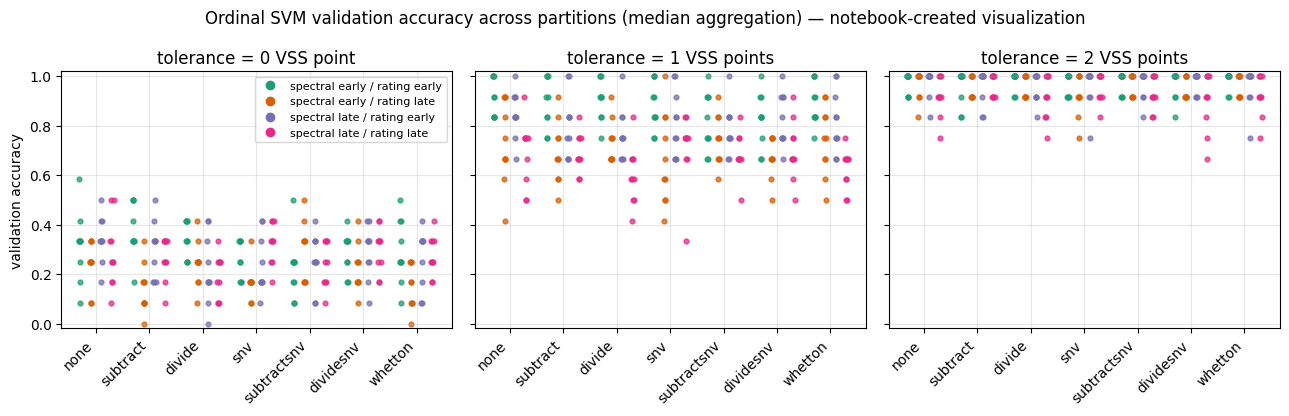

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), sharey=True)
combos = sorted({(r.date_spectral, r.date_rating) for r in res.itertuples()})
colors = dict(zip([("early", "early"), ("early", "late"),
                   ("late", "early"), ("late", "late")],
                  ["#1b9e77", "#d95f02", "#7570b3", "#e7298a"]))
for ax, tol in zip(axes, (0, 1, 2)):
    for scheme in SCHEMES:
        for ci, (ds, dr) in enumerate(combos):
            sub = res[(res.tolerance == tol) & (res.preprocessing == scheme) &
                      (res.date_spectral == ds) & (res.date_rating == dr)]
            accs = (sub.n_hit / sub.n_val).to_numpy()
            x = SCHEMES.index(scheme) + (ci - (len(combos) - 1) / 2) * 0.2
            ax.scatter(np.full(len(accs), x) + np.random.default_rng(ci).normal(0, 0.01, len(accs)),
                       accs, s=12, color=colors[(ds, dr)], alpha=0.75)
    ax.set_title(f"tolerance = {tol} VSS point" + ("s" if tol else ""))
    ax.set_xticks(range(len(SCHEMES)))
    ax.set_xticklabels(SCHEMES, rotation=45, ha="right")
    ax.set_ylim(-0.02, 1.02)
    ax.grid(alpha=0.3)
axes[0].set_ylabel("validation accuracy")
handles = [plt.Line2D([], [], marker="o", ls="", color=colors[c],
                      label=f"spectral {c[0]} / rating {c[1]}") for c in combos]
axes[0].legend(handles=handles, fontsize=8)
fig.suptitle("Ordinal SVM validation accuracy across partitions (median aggregation) — "
             "notebook-created visualization")
fig.tight_layout()
plt.show()

## Export — per-ensemble validation results (CSV)

**JP:** 結果表をCSVとして保存します(左のファイルパネルからダウンロードできます)。

In [ ]:
res.to_csv("/content/fhb_svm_validation_accuracy.csv", index=False)
print("saved /content/fhb_svm_validation_accuracy.csv,", len(res), "rows")
res.head()

saved /content/fhb_svm_validation_accuracy.csv, 840 rows


,date_spectral,date_rating,preprocessing,partition_id,tolerance,n_val,n_hit,part_acc
0,early,early,none,1,0,12,3,0.250000
1,early,early,none,1,1,12,12,1.000000
2,early,early,none,1,2,12,12,1.000000
3,early,early,none,2,0,12,4,0.333333
4,early,early,none,2,1,12,10,0.833333


## Interpretation, differences from the paper, validation record, references

**What this demonstrates:** on the retained hill-plot pairs, ordinal RBF-SVM ensembles trained
on median-aggregated 425–2275 nm spectra reproduce the paper's evaluation protocol (3:1
jack-knife ×10, 0/1/2-point tolerance). Compare the printed table/figure with §3.2/Fig. 5:
zero-tolerance accuracy is expected to be modest, early-date ratings with 1-point tolerance
high, 2-point tolerance near 100%, and late-date (wax-ripening) ratings deteriorated.

**Documented differences from the author implementation** (behavior-preserving unless stated):
(1) Python/sklearn port instead of R/e1071+mlr — same tree, same 2^x grid bounds and
LOO-accuracy criterion, same fallbacks; tie-breaking order in the grid may differ from `mlr`;
(2) partition *membership* differs (NumPy RNG stream vs R) while the protocol is identical;
(3) precomputed-kernel LOO and fitting (asserted ≡ `rbf`); (4) Savitzky–Golay edges via scipy
constant-NaN mode, interior values matching the author's `prospectr::savitzkyGolay` window;
(5) scope: median aggregation only — mean aggregation, `brms` posterior modelling and remaining
figures omitted. This is **not** a reproduction of dataset-level paper metrics — a single
pre-registered trial's minimal demonstration.

**References:** Żelazny, Chrpová & Hamouz (2021) *Biosystems Engineering* 211:97–113, DOI
10.1016/j.biosystemseng.2021.08.019 (CC-BY). Data/code: Zenodo 4536881 v1.0.0, AGPL-3.0 — key
author functions ported: `R/constants.R`, `R/01-wrangle.R`, `R/02-partition.R`,
`R/04-reflectance.R` (`trim`, `parabolic_corr`), `R/05-aggregate.R`, `R/06-preprocess.R`,
`R/07-model.R` (`svm_fit`, `ordinal_svm_fit`), `R/08-predict.R` (`ordinal_svm_predict`),
`R/09-add_tolerances.R`, `R/10-confmatrix.R`, `R/11-evaluate.R`. Ordinal decomposition after
Behmann et al. (2014b); pre-processing scheme 7 after Whetton et al. (2018b). Full text
obtained via OpenAlex work W3199920909.

**JP:** 本ノートブックは論文の評価プロトコル(3:1ジャックナイフ×10、許容誤差0/1/2)を再現する最小デモです。R実装からの変更点(乱数ストリーム、カーネル事前計算等)は全て上記に明記しており、データセット全体の論文水準の再現ではありません。